In [1]:
from google.colab import files
uploaded = files.upload()

Saving embeddeddf.csv to embeddeddf.csv


In [3]:
import pandas as pd

In [22]:
df = pd.read_csv("embeddeddf.csv")

In [23]:
def fix_embedding_string(s):
    s = s.strip("[]")  # remove brackets
    return [float(x) for x in s.split() if x]  # split by space, convert to float


df['embedding'] = df['embedding'].apply(fix_embedding_string)




In [38]:
df.dtypes

,0
id,int64
log_price,float64
property_type,object
room_type,object
amenities,object
accommodates,int64
bathrooms,float64
bed_type,object
cancellation_policy,object
cleaning_fee,bool


In [6]:
from sklearn.cluster import KMeans

In [24]:


# Convert stringified embeddings back to real lists
X = np.array(df['embedding'].tolist())  # Convert to numpy array

print(X.shape)  # Should be (74111, 384) or similar


(74111, 384)


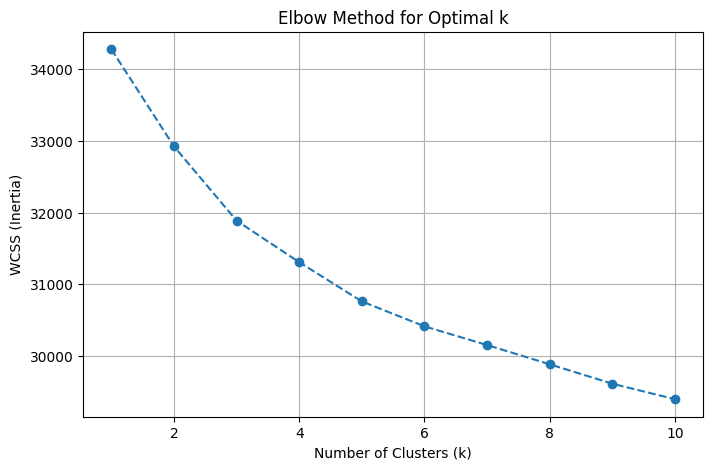

In [25]:
# Now apply KMeans
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [27]:
!pip install kneed

In [28]:
from kneed import KneeLocator  # Make sure to install with: pip install kneed
# Elbow method - compute inertia
inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init="k-means++")
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Use KneeLocator to find the elbow point
knee = KneeLocator(cluster_range, inertia, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print(f"Optimal number of clusters according to KneeLocator: {optimal_k}")

Optimal number of clusters according to KneeLocator: 5


In [29]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [31]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Add PCA components to DataFrame for plotting
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]


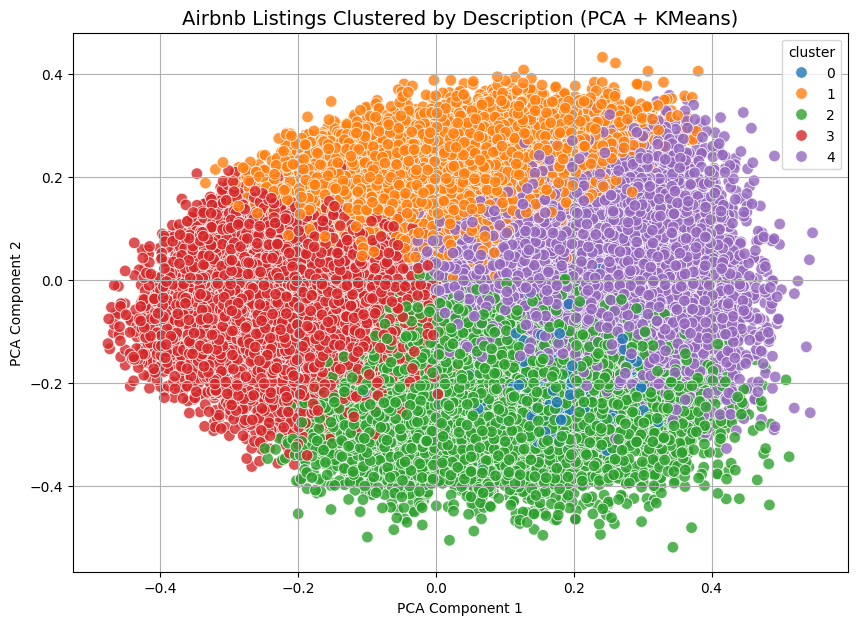

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='tab10',
    data=df,
    legend='full',
    s=70,
    alpha=0.8
)

plt.title('Airbnb Listings Clustered by Description (PCA + KMeans)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()


In [33]:
df[df['cluster']==0]['description'].value_counts()

,count
description,
#NAME?,6
"æœ¬åœ°æ–¹æ˜¯ä¸ªä¸¤å±‚æ¥¼townhouseæ¸©é¦¨ä¹‹å®¶,ä¸€æ¥¼æˆ‘ä»¬è‡ªå·±ä½,äºŒæ¥¼äº”ä¸ªæˆ¿é—´åšå‡ºç§Ÿæˆ¿,æœ‰ä¸¤ä¸ªæ´—æ‰‹é—´å’Œæµ´å®¤ä¾›æ‚¨ä»¬ä½¿ç”¨,æ¯ä¸ªæˆ¿é—´éƒ½é…å¤‡åŒäººåºŠ è¢«å­æž•å¤´åºŠå¤´æŸœ å°ç¯ ä¹¦æ¡Œæ¤… ç”µè§†æœºWi-Fi çƒ­æ°´å£¶ æ¯›å·¾ç‰™åˆ· ç‰™è† æ‹–éž‹ é¤å·¾çº¸ æˆ¿é—´å¹²å‡€å«ç”Ÿã€‚å¤§é—¨è¿›å‡ºæœ‰å¯†ç é” æ¯ä¸ªæˆ¿é—´ä¹Ÿéƒ½æœ‰å¯†ç é” èµ°å»Šæœ‰å®‰è£…ç”µçœ¼æŽ¢å¤´,åŽ¨æˆ¿å¯ä»¥ç…®ç®€å•çš„é£Ÿç‰©,å¯ä»¥è¯´æ˜¯éº»é›€è™½å°äº”è„ä¿±å…¨ã€‚ åœ°æ–¹ä½äºŽçº½çº¦å¸ƒé²å…‹æž—å…«å¤§é“åŽäººé›†èšåœ°,é™„è¿‘å„ç§é¤é¦†æž—ç«‹,åœ°åŒºæ²»å®‰å¥½äº¤é€šå‘è¾¾,èµ°è·¯2åˆ†é’Ÿåˆ°å°å·´ç«™25åˆ†é’Ÿè½¦ç¨‹åˆ°è¾¾æ›¼å“ˆé¡¿å”äººè¡—,é—¨å£æœ‰å¤§å·´ç«™åä¸¤ç«™åˆ°åœ°é“ç«™ä¹Ÿå¯ä»¥èµ°è·¯8åˆ†é’Ÿåˆ°Nåœ°é“ç«™æˆ–èµ°12åˆ†é’Ÿåˆ°Dæˆ–Råœ°é“ç«™ã€‚ å¦‚æžœæ‚¨å¼€è½¦è¿‡æ¥ç™½å¤©å¾ˆå®¹æ˜“æ‰¾åˆ°è½¦ä½,æ™šä¸Š8ç‚¹åŽå¦‚æžœæ‰¾ä¸åˆ°è½¦ä½,æ‚¨å¯ä»¥æŠŠè½¦åœåœ¨æˆ‘ä»¬æ—è¾¹8å¤§é“meterè½¦ä½ä¸Šç›´åˆ°ç¬¬äºŒå¤©æ—©æ™¨7ç‚¹åŠåŽå°±æœ‰å¾ˆå¤šè½¦ä½äº†,æ¬¢è¿Žæ‚¨çš„åˆ°æ¥!",4
.,3
"Quiet community. Close to supermarkets,restaurants,60 freeway.Looking forward to provide you with high quality service å®‰å…¨å®é™çš„è¡—åŒº, è¿‘åŽäººåŠéŸ©å›½è¶…å¸‚,é¤åŽ…,è¿‘60å·é«˜é€Ÿã€‚æ¬¢è¿Žæ—…è¡Œå•†ä½ å®½æ•žã€æ˜Žäº®ã€å¹²å‡€ã€æ•´æ´ã€å‡ºå…¥æ–¹ä¾¿ Available kitchen,laundry,living room å¯ä½¿ç”¨åŽ¨æˆ¿æ´—è¡£é—´åŠå®¢åŽ… Anytime contact with message or email.phone call available 9am to 7pm. ä»»ä½•æ—¶é—´çš„ä¿¡æ¯å’Œé‚®ç®±éƒ½å¯ä»¥ã€‚ç”µè¯è¯·åœ¨å¤ªå¹³æ´‹æ—¶é—´æ—©ä¸Š9ç‚¹è‡³æ™šä¸Š7ç‚¹ä¹‹é—´ æˆ¿å®¢é¡»çŸ¥: 1ã€æˆ¿å®¢ä¹‹é—´ä¸å…è®¸ç§ä¸‹æ“…è‡ªæ›´æ¢æˆ¿é—´,å¿…é¡»ç»ç”±ç®¡ç†å‘˜,ä»¥åŠåŒæ–¹æˆ¿å®¢è®¸å¯,ç”±ç®¡ç†å‘˜ç›‘ç£æ›´æ¢æˆ¿é—´ã€‚ 1, between the tenants are not allowed to privately change the room, must be by the administrator, and the two sides permit tenants, supervise the replacement of the room by the administrator. 2ã€è¯·è®¤å‡†è‡ªå·±é¢„å®šæˆ¿é—´çš„å·ç æ‹¿å–é’¥åŒ™,ä¸å¾—è¿›å…¥éžé¢„å®šæˆ¿é—´ã€‚ 2, please look for their own room number to pick up the key, not to enter the not you booking room. 3ã€é¢„å®šæˆ¿é—´è¯·çœ‹å‡†æè¿°é€‰å®šæˆ¿é—´,å¦‚æè¿°ä¸æ¸…è¯·å‘ç®¡ç†å‘˜å’¨è¯¢,é¢„å®šåŽæ—¢è§†ä¸ºè®¤å¯ä¸ç»™äºˆä»»ä½•æ›´æ¢ã€‚ 3, booking room, please see the description of the selected room, such as the description is unclear, please ask to the administrator, when confired booked room,we don't given any replacement. 4ã€è¯·è‡ªè¡Œç¡®è®¤æ˜¯å¦é¢„å®šæƒ³è¦çš„æˆ¿æº,å¦‚ä¸æ¸…æ¥šè¯·åŠæ—¶è¯¢é—®ç®¡ç†å‘˜,å¦‚ç¡®è®¤é¢„å®š,ç®¡ç†å‘˜æ—¢è§†ä¸ºæ»¡æ„æœ¬æˆ¿æº,ä¸å†å¯¹é¢„å®šè¿›è¡Œ",3
"æˆ‘çš„æˆ¿æºé è¿‘æ ¸æ¡ƒæ ¸å¿ƒåœ°æ®µç‹¬ç«‹æˆ¿å±‹,äºŒå±‚å››æˆ¿ä¸‰æµ´2000å°ºå‡ºç§Ÿ,å¥—æˆ¿é›…æˆ¿éƒ½æœ‰,å¯æ­¥è¡Œåˆ°å°å­¦ä¸­å­¦é«˜ä¸­,å‘¨è¾¹é…å¥—è®¾æ–½å®Œå–„,é“¶è¡Œ,è€ç¾Žè¶…å¸‚ä¹Ÿå¯æ­¥è¡Œåˆ°ã€‚è·ç¦»ç½—å…°å†ˆå•†ä¸šåŒºå¼€è½¦ä¹Ÿåœ¨ååˆ†é’Ÿå†…ã€‚é•¿ç§ŸçŸ­ç§Ÿçš†å®œ[å¾®ç¬‘]æ‹ŽåŒ…å…¥ä½!!å¾®ç¬‘/å¾®ç¬‘ã€",2
...,...
"äº¤é€šæ–¹ä¾¿,è¿‘å­¦æ ¡,å¤§åž‹å•†åœº,æ­¥è¡Œå¯è‡³æ‰€æœ‰ç”Ÿæ´»æ‰€éœ€, é™„è¿‘å…¬å…±è®¾æ–½åŒ»é™¢çš†æœ‰ä¸­æ–‡æ ‡ç¤º,å‰å›­åŽé™¢,çŽ¯å¢ƒä¼˜é›…,é«˜é€Ÿä¸Šç½‘,æ´—è¡£çƒ˜ä¹¾å‡€æ°´å™¨,å¯ä½¿ç”¨å¾®æ³¢ç‚‰å†°ç®±å¹¶ç®€ç‚Š,å¤§åºŠ! ç§äººå¥—æˆ¿ç¨ç«‹è¡›æµ´,å®¶å…·é½Šå…¨,å¤§é›™äººåºŠ,ä¸­å¿ƒåŒºé—¹ä¸­å–é™,å¯æ™¨èµ°å¤œè·‘,å›­ä¸­æ ‘å¤š,ä¾†å®¢èª‰ä¸ºå¤©ç„¶æ°§å§,èŠ±å­£æœ‰èœ‚é¸Ÿé€ è®¿,æ­¥è¡Œè‡³ä¸­è¥¿è¶…å¸‚é¤é¦†è¯æˆ¿é“¶è¡Œ,å±‹ä¸»æä¾›è‡ªè¡Œè½¦!ä½è€…çš†è§‰ä»·å»‰ç‰©ç¾Ž,ç‰©è¶…æ‰€å€¼ã€‚ æˆ¿é—´,åŽ¨æˆ¿å’Œç”¨é¤å€åŸŸ è¦–æˆ¿å®¢éœ€è¦ç«­å°½æ‰€èƒ½ã€‚ ç½—å…°å²—ä¸­å¿ƒ,æ­¥è¡Œä¸‰äº”åˆ†é’Ÿå¯è‡³å…¬è½¦ç«™,åŠä¸­è¥¿é¤é¦†è¶…å¸‚,é“¶è¡Œè¯æˆ¿ã€‚ å¼€è½¦ä¸‰åˆ†é’Ÿ: 1. ä¸Šé«˜é€Ÿå››é€šå…«è¾¾,2. å„ç±»å¤§åž‹å•†åœº,3. å¤§å…¬å›­å¯é‡Žç‚Šå¥è¡Œçˆ¬å±±,4. å·¥ä¸šå¸‚åŠžå…¬åŒº; æ­¥è¡Œä¸‰äº”åˆ†é’Ÿå¯è‡³å…¬è½¦ç«™: 1. è¿žä¸Šæ´›æ‰çŸ¶å…¬å…±äº¤é€šç³»ç»Ÿ,2. å…©ä¸‰ç«™åˆ°å„å¤§åž‹å•†åŸŽåŠå¤§å…¬åœ’,3. 40åˆ†è‡³åŸŽä¸­å¿ƒå€ã€‚æ´›æ‰ç£¯æ‰€æœ‰å…¬å…±äº¤é€šçš†æ‰¿è¼‰è‡ªè¡Œè»Š,æ­¡è¿Žå€Ÿç”¨,çæƒœ,ç¶­è­·! æ´›æ‰çŸ¶ä¹¾ç‡¥æ—¥å¤œæ¸©å·®å¤§,åŒºåŸŸå¹¿ä¸Žå…¸åž‹ä¸­å›½åŸŽå¸‚ä¸åŒ,å®œä¸Žè‡ªç„¶çŽ¯å¢ƒå…±å¤„ã€‚",1
Come stay with me! STR-(PHONE NUMBER HIDDEN) Registration Number: STR-(PHONE NUMBER HIDDEN),1
"äº¤é€šç‰¹åˆ«æ–¹ä¾¿,ç‹¬æ ‹åˆ«å¢…!è¿‘åŽäººè¶…å¸‚,åŽäººé¥­

In [34]:
df[df['cluster']==1]['description'].value_counts()

,count
description,
"HUGE loft in converted factory, with in building: -COFFEE SHOP -YOGA STUDIO -ROOF DECK -FOOD CO/OP -TATTOO PARLOR -VAPE SHOP -CLOTHING STORES -SHIPPING AND PRINTING STORE -Located in vibrant Bushwick Brooklyn within walking distance to some of the best street art in the US. -Just 3 blocks to subway with easy access to Manhattan, Williamsburg and JFK airport. At your disposal is a comfortable lounge and dining area with a kitchen, and 2 bathrooms, that is all cleaned daily. There is also a HUGE ROOF DECK, as well as mini mall downstairs containing a yoga studio, coffee shop, art gallery, skate shop, and clothing store. Right across the street are 2 of the biggest vintage shops in Brooklyn. Your room has a brand new super comfortable PILLOW TOP double bed, as well as your own air conditioner and space heater to combat extreme NYC temperatures. Free WIFI :) We pay for extra for the really fast internet so stream video at ease. We also provide professionally laundered fresh sheets and to",4
"Come stay in my converted townhome in the heart of Bedford-Stuyvesant. Close to great restaurants, coffeeshops and juice bars, a great place to lay your head after a day or night out on the town. You will have a private room on the middle floor with a full sized bed and clean sheets and towels. There are 4 bathrooms, one on each floor, a living room and a fully equipped kitchen to use. I live on site and will be available to help with anything that you may need or neighborhood suggestions. A great mix of the hip and gentrified new Brooklyn, and the old 'real' Brooklyn. Im just a stones throw form great Jamaican food, cold brew coffee and juice shops. Just a 7 min walk to the G or AC trains and just 30 minutes into downtown manhattan.",4
"Remarkably located in the heart of Chelsea in Manhattan, within walking distance of Penn Station, Madison SquareGarden, High Line Park and Theater District our hostel type separate rooms are simple, cozy, and very clean. Although small in size they are centered around a spacious common lounge area with free WiFi. We are located in the heart of the historic Chelsea neighborhood, West Side Manhattan: between 28th and 29th Streets on 8th Avenue. The freshly renovated hostel rooms here are simple, cozy, and very clean. Our management crew is on-site 24/7 to make sure everybody is happy. There is free WiFi here. Fresh, clean sheets, pillows towels and blankets are there for you. Although small in size the retreat guest rooms here are centered around a spacious common area. As a friendly, peaceful atmosphere, the common room is a perfect getaway from your busy day in the city. There is also a small library of spiritual books that can keep your mind engaged during a respit from the busy stree",3
"The Wyndham Midtown 45 is a serene, sophisticated oasis in the heart of midtown Manhattan. Located on 45th Street between 2nd and 3rd Avenues, Wyndham Midtown 45 is within walking distance of many of New York Cityâ€™s major attractions and business centers! This space is situated close to Grand Central Terminal, 5th Ave (shopping!!!) and the New York Public Library. A perfect destination for couples, solo adventurers, families and big groups!! An intimate lobby, serene surroundings, limestone baths, rain showers, and plush bedding are just a few of the amenities you'll enjoy at my Wyndham Midtown 45 condo. Guest amenities and services include: Business Center Enjoy spectacular views from the 33rd Floor Sky Lounge, featuring indoor and outdoor seating. Open daily from 7AM- 11PM Complimentary coffee, tea, and infused water served throughout the day in the lobby Flat Screen HD televisions in every living room, bedroom, and bathroom Complimentary Wifi Internet in all gu",3
"Welcome to my home! It's a nice, newly renovated brownstone townhouse in the heart of Brooklyn. Close to major train lines: 1 minute to the J train and 4 minutes to the C train. Both trains will get you to manhattan in 15-20 minutes. My p

In [35]:
df[df['cluster']==2]['description'].value_counts()

,count
description,
"Brand New 2017 Construction, Featuring 2 Bedrooms and 2 bathrooms . comfortable couch, coffee table, 50-inch TV in living room, with free Satellite Cable channel and internet Wi-Fi. Washer and Dryer in the building on each floor.This lovely Apartment is perfect for families, couples or four close friends! With over 900 square feet of living space.A short freeway ride to Westwood, Hollywood Bowl, Griffith Park, LA Zoo, and downtown venues such as Chinatown, LA Live, Staples Center and Olivera St. Enjoy the open entertainer floor plan featuring a gourmet kitchen with quartz counters w/natural mosaic stone and quartz back splash, Stainless Steel appliances, and designer cabinetry. All baths are tastefully done with tub/showers and sinks. Awesome living area, Enjoy those high ceilings! Terrific master suite with closet space. This is a ""smart home"" featuring an LED recessed lighting. Gated Garage is ready for two full sized cars all side by side. A cozy retreat for your stay in Los Angele",5
"A very cozy house located in the heart of Hollywood between two famous streets: Beverly Blvd and Melrose Ave, within a safe and quiet neighborhood, 30 minutes from LAX, 15 minutes from Downtown LA, 15 minutes from Griffith Observatory, 15 minutes from Hollywood Walk of Fame, 15 minutes from Universal Studios, 5 minutes from Paramount Pictures. There are lots of restaurants and shops nearby. My favorite is Osteria La Buca:) A great house in the central area of Los Angeles suitable both for travelers and business trips. It is fully equipped with all you need and freshly renovated. FREE PARKING:)",4
"Our unique building is located in the Silicon Beach, directly across the street from (SENSITIVE CONTENTS HIDDEN) in Playa Vista. Fully remodeled designer-done 4-plex walking distance to the Playa Vista Runway, (SENSITIVE CONTENTS HIDDEN), YouTube, IMAX, Belkin, FOX, and (SENSITIVE CONTENTS HIDDEN). Two one-bedroom units and two studio units have all been remodeled by a high-end designer in 2015 Our place is good for couples, solo adventurers, and business travelers. Sorry, no pets. Units 1 & 2 are downstairs, 3 & 4 are upstairs. The building has one set of professional coin operated washer and dryer machines, shared by all four units. The laundry room is located towards the back of the building, near the back gate. You will have access to one (and only one) off-street parking spot in the back of the building. When confirming your booking, please inform the model, color and license plate of the car you will have throughout your stay - that way we can control who's illegally parked and s",4
"Spacious 2 story 4000 sqft home Enjoy fruit trees swimming pool fountain & gardens lWalking distance to mall, grocery store, movie theater & restaurants. Centrally located to Malibu, Santa Monica,Venice,Hollywood, Beverly Hills, West LA This spacious 2 story 4000 sqft home is fully furnished and beautifully decorated! Coffee and donuts are served every morning;) Please keep in mind that this is a shared space, and that your large room consists of 2 bunk beds, your own dresser, hamper, and closet space. You will have full access to the rest of the home. We provide a safe, clean, and positive environment, perfect for people relocating from out of state, students, and anyone else who needs a landing place while traveling. Near public transportation; ORANGELINE, 405, and 101 FREEWAYS. You will have full access to the rest of the home. We do have private and 2 person and or couples rooms available in the same property. Full kitchen privileges All Premium Cable and movie channels Full se",4
"Downtown LA CubeSpace bed in shared room. Make friends and good memories. Located in the heart of downtown LA in the flower district. All beds have curtains and TVs with Netflix. There is a common area and kitchen that all guest can use. I offer coffee and tea all day. Oatmeal for breakfast and I sometimes make pastries from scratch. I have a washing machine, 

In [36]:
df[df['cluster']==3]['description'].value_counts()

,count
description,
"Hello, I've been running guest house for Koreans visiting U.S. for 3years, and recently decided to run this place for other travelers also. There are 10 room in the house. They are mostly dormitory rooms and couple of couple room and family room. This places are our women's dormitory in third floor. There are three rooms, but no doors. It is basically open space. There are 2 beds in two rooms and 4 in one room. I do not have closet in this room but there are hangers and mini shelves. My travelers usually put their baggage on the floor. There is one full bathroom only for women in 2nd floor, which you will be sharing with other women guests. Right next that bathroom, there is unisex half bathroom. All bathrooms have hair dryers. You cannot use kitchen, but you can use refrigerator. I offer breakfast every morning from 7-10 am. Bread, cereal, fruits, coffee, milk and juice will be served. You can eat take-out food in the kitchen, but please wash dishes that you used and put trash in the",8
"Welcome to RMH, a co-ed hostel vibe home for exploring travelers or working individuals needing temporary housing. (Guests access is from 3pm to 11am daily). NON-SMOKERS ONLY! Host & small dog live on property. NOTE: Guests' bedroom is dog free. GUARANTEED In Our Home: *You receive a clean home in a safe neighborhood, clean sheets, pillow, towel and covers. **You MUST Read House Rules BEFORE Booking :) ***IMPORTANT ***SMOKERS who book: reservation cancelled upon arrival + NO Refund. The bedroom is very large with enough space for everyone (6 guests) to have peace and quiet. The kitchen and bath are very spacious. Guests will have their own keys and have access to the bedroom in which they stay, kitchen, bathroom, living room and deck. OPTIONAL: (Normal Check IN is 3pm, Check OUT is 10am) If you would like an EARLY CHECK IN before 3pm ($25 fee) Guests trying to check in after 10pm will need to get pre-approval from host and pay the late check in fee of $25. There is no key box and no gu",6
"OutpostClub is a network of Coliving locations throughout NewYork. We built it to make it super easy to move to NewYork, and to provide cool convenient places for cheap. Coliving - is a shared housing model - where you share kitchen, living rooms, common spaces with others, having private or shared bedrooms of your choice. Everything is included in the flat fee - utilities, furniture, supplies, events. Book Now, grab your suitcase and move into the House, meet people who will become your friends Coliving Club is a beautifully curated living space in New York with a wide range of amenities such as free workspace with printer and scanner, hi-speed Wi-Fi, fully equipped kitchen, dinner and living space, private backyard, individual safe, coffee, tea, soda, shampoo, shower gel, hand soap, towels and much more! Everything is included in our flat fee. Here we thoroughly picked every detail so that you feel cozy. Expect a great night's sleep with our made in USA memory foam mattresses by Broo",5
"2 Bedroom, 2 Bathroom, Sleeps 6: Max 5 Adults and 1 Child (not more than 12 yrs old) A stunning impeccably kept furnished apartment in a prime location within the City. Innovative design, spacious floors with full size kitchen and living area , we have washer and dryer, a luxurious beddings, linens and furnishings in bedrooms and bathrooms. With FREE access to WiFi, Fitness Center, Indoor Pool, Sauna & Steam Rooms, and Jacuzzi and BbQ area. A perfect city oasis of comfort and luxury. Perfectly designed. Expertly finished and furnished to very high specifications. A spacious and modern layout apartment, comprises of well equipped kitchen,large combined living/dining area, large bedroom, bathroom and close to all amenities. Centrally located, within walking distance to City. Enjoy FREE access to high speed internet, outdoor pool with adjacent lounge and multipurpose room, a two-story fitness center featuring LifeFitness Elevation Series cardio and Signa

In [37]:
df[df['cluster']==4]['description'].value_counts()

,count
description,
"Private room in the heart of Little Italy with FREE PARKING :) You will have your own personal door code and may arrive at ANY time you would like and as late as you wish. You can store your luggage in the closet before check-in and after check-out times :) Price adapts to demand, my rates change constantly - every night is different! Put your dates in the calendar, with the number of guests, and what you see is what you'll pay :) The neighborhood is extremely safe even at night :) Restaurants and bars are right round the corner, both upscale and casual. This room is 6 minutes away by car or uber to Chicago's famous Willis (Sears) tower. Uber costs about $7. If you are arriving by car, I am providing free resident parking passes for anywhere in the area. (Yes, that means you can drive a few blocks and still park anywhere you want!) The room will be solely yours for the time you'll stay in the Windy City. Shall you have any concerns or need any tips from the local, I'll always be happy",7
"Perched on the historic C&O Canal, the Georgetown House is an intimate boutique inn offering its guests 11 newly appointed rooms in the heart of quintessential Georgetown. Behind its bright red door and gray brick facade, lays a world of history unbeknownst to even some of its local visitors. Originally established and built in the 1830's, the building was initially constructed for use by the Chesapeake & Ohio Canal Company. Behind its bright red door and gray brick facade, lays a world of history unbeknownst to even some of its local visitors. Originally established and built in the 1830's, the building was initially constructed for use by the Chesapeake & Ohio Canal Company for storage of its equipment as they worked to build the canal and its lock system. Shortly thereafter it was renovated into a stable where horses or mules drawing the barges were kept below while the drivers lived above. After there was no need for mules and horses, the house was turned into a tavern. While the b",5
"At the intersection of the charming Leather District, bustling Chinatown, and the Theater Districtâ€™s entertainment hub, this apartment offers countless opportunities to fully immerse yourself in Boston city life. Guests can live comfortably in a spacious living space with one bed, a fully-equipped kitchen, and soaring ceilings. Guests can also take advantage of the many amenities the building offers. 2 bedrooms, 2 bathrooms, sleeps 5 Discover unsurpassed city living in these thoughtfully designed, sophisticated apartment residences. Nestled right where Bostonâ€™s Leather District, Chinatown, and the Theater District converge, youâ€™re in the fast lane to every major Boston attraction. The 19th century brick and stone architecture that characterizes The Leather Districtsâ€™ famous South Street, provides the backdrop for quite a romantic date night. Looking for a night out with friends? The Theater District is the home to many classic theaters, musicals, concerts, ballets, and drama. And wh",5
My place is good for business travelers.,4
"Beautiful, comfortable, clean, cozy rooms near shopping mall, diner, and public transportation.",4
...,...
"Close to Central park, the Met, Guggenheim. On a beautiful tree-lined block in a safe quiet neighborhood. Tons of great restaurants and bars, a block from the subway. Loft apartment, fully equipped kitchen, has a piano. Queen-size bed upstairs, a couch that opens into a king-size bed downstairs. Wifi, Apple TV - Netflix, Hulu, HBO Now. Breakfast foods. Street parking, garage, cleaning service. The place is quite small and not very fancy, but it's cozy and has everything you need. No pets. Entire apartment I'll be available to answer any questions, help plan your stay, give restaurant recommendations, get you last-minute Broadway or opera tickets or help you in case of any emergency. Some neighborhood favorites: Thai: Thais - 89 & 2, Pye Boat Noodle - 89 & 2, Vietnamese: Pho Shop - 89 & 1 Mexican: S

### Cluster 1: New York City Accommodations
- **Location**: Primarily in Brooklyn and Manhattan, close to public transport and key areas.
- **Amenities**: Shared spaces, modern conveniences (Wi-Fi, air conditioning), unique features like yoga studios, coffee shops, and rooftop decks.
- **Community Feel**: Emphasizes communal atmosphere with shared spaces and proximity to local spots like restaurants and cafes.
- **Comfort**: Clean, well-maintained rooms with essentials such as fresh linens and air conditioning.

### Cluster 2: Major Urban Areas (Los Angeles, San Francisco)
- **Location**: Proximity to tourist attractions, entertainment districts, business centers, and public transportation (metro stations and airports).
- **Amenities**: Modern living spaces with Wi-Fi, smart home capabilities, and shared areas like kitchens and bathrooms.
- **Target Audience**: Vacationers, business travelers, families, and people relocating.
- **Comfort**: Comfortable furnishings with recreational options like pools and gyms.

### Cluster 3: Shared Spaces and Host Interaction
- **Shared Spaces**: Emphasis on communal living areas like kitchens, bathrooms, and living rooms.
- **Cleanliness and Comfort**: Well-maintained accommodations with fresh linens and towels.
- **Location**: Centrally located with easy access to public transport and attractions.
- **Host Interaction**: Varying levels of host support, ensuring comfort and assistance during the stay.
- **Diverse Room Types**: Options ranging from private rooms to dormitory-style accommodations for different needs and budgets.

### Cluster 4: Convenience and Accessibility
- **Location**: Central, convenient locations near major landmarks and popular districts (e.g., Little Italy, Georgetown, Washington, D.C.).
- **Amenities**: Wi-Fi, kitchens, entertainment options, and additional services like breakfast, cleaning, and local transportation.
- **Special Services**: Features catering to specific events or unique offerings like pools, yoga, or scenic views.
- **Guest Experience**: Hosts provide personalized service, local recommendations, and a comfortable, home-like atmosphere.
